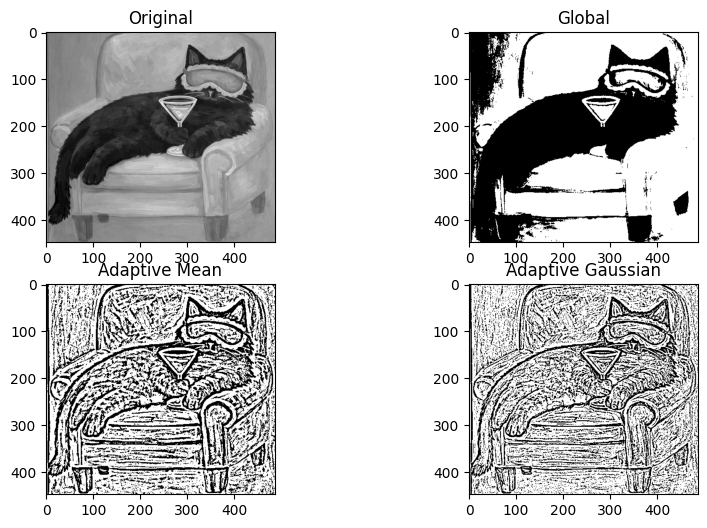

In [3]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("C:\\Users\\ind81\\OneDrive\\Pictures\\Screenshots\\Screenshot 2026-02-26 195009.png", 0)
_, global_thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
adaptive_mean = cv2.adaptiveThreshold(img, 255,
                                      cv2.ADAPTIVE_THRESH_MEAN_C,
                                      cv2.THRESH_BINARY, 11, 2)
adaptive_gaussian = cv2.adaptiveThreshold(img, 255,
                                          cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                          cv2.THRESH_BINARY, 11, 2)
plt.figure(figsize=(10,6))
plt.subplot(221), plt.imshow(img, cmap='gray'), plt.title("Original")
plt.subplot(222), plt.imshow(global_thresh, cmap='gray'), plt.title("Global")
plt.subplot(223), plt.imshow(adaptive_mean, cmap='gray'), plt.title("Adaptive Mean")
plt.subplot(224), plt.imshow(adaptive_gaussian, cmap='gray'), plt.title("Adaptive Gaussian")
plt.show()

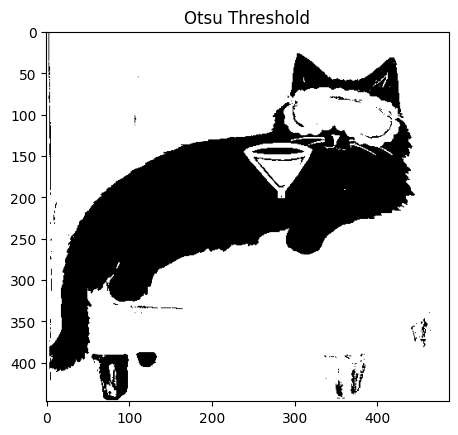

In [4]:
import cv2
import matplotlib.pyplot as plt
img=cv2.imread("C:\\Users\\ind81\\OneDrive\\Pictures\\Screenshots\\Screenshot 2026-02-26 195009.png",0)
_,otsu_thresh=cv2.threshold(img,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
plt.imshow(otsu_thresh,cmap='gray')
plt.title("Otsu Threshold")
plt.show()

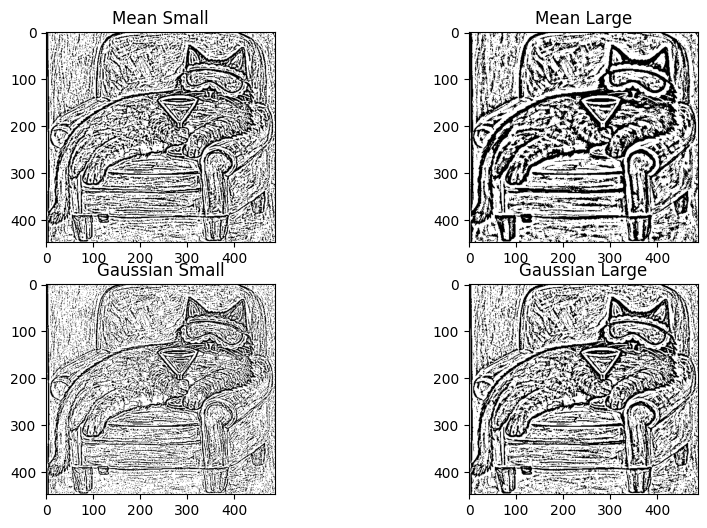

In [5]:
import cv2
import matplotlib.pyplot as plt

img=cv2.imread("C:\\Users\\ind81\\OneDrive\\Pictures\\Screenshots\\Screenshot 2026-02-26 195009.png",0)

mean_small=cv2.adaptiveThreshold(img,255,cv2.ADAPTIVE_THRESH_MEAN_C,cv2.THRESH_BINARY,7,2)
mean_large=cv2.adaptiveThreshold(img,255,cv2.ADAPTIVE_THRESH_MEAN_C,cv2.THRESH_BINARY,15,2)

gauss_small=cv2.adaptiveThreshold(img,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY,7,2)
gauss_large=cv2.adaptiveThreshold(img,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY,15,2)

plt.figure(figsize=(10,6))
plt.subplot(221),plt.imshow(mean_small,cmap='gray'),plt.title("Mean Small")
plt.subplot(222),plt.imshow(mean_large,cmap='gray'),plt.title("Mean Large")
plt.subplot(223),plt.imshow(gauss_small,cmap='gray'),plt.title("Gaussian Small")
plt.subplot(224),plt.imshow(gauss_large,cmap='gray'),plt.title("Gaussian Large")
plt.show()

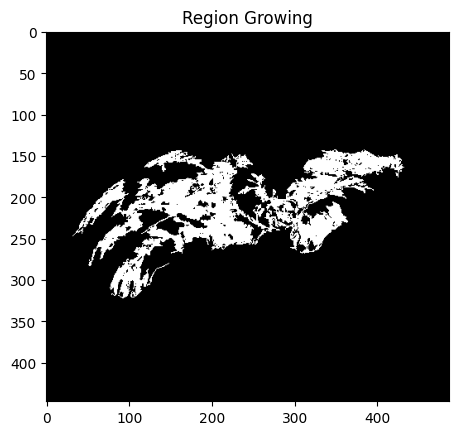

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img=cv2.imread("C:\\Users\\ind81\\OneDrive\\Pictures\\Screenshots\\Screenshot 2026-02-26 195009.png",0)

h,w=img.shape
seg=np.zeros((h,w),dtype=np.uint8)
seed=(h//2,w//2)
stack=[seed]
threshold=10
seed_val=img[seed]

while stack:
    x,y=stack.pop()
    if seg[x,y]==0:
        seg[x,y]=255
        for dx in [-1,0,1]:
            for dy in [-1,0,1]:
                nx,ny=x+dx,y+dy
                if 0<=nx<h and 0<=ny<w:
                    if abs(int(img[nx,ny])-int(seed_val))<threshold:
                        stack.append((nx,ny))

plt.imshow(seg,cmap='gray')
plt.title("Region Growing")
plt.show()

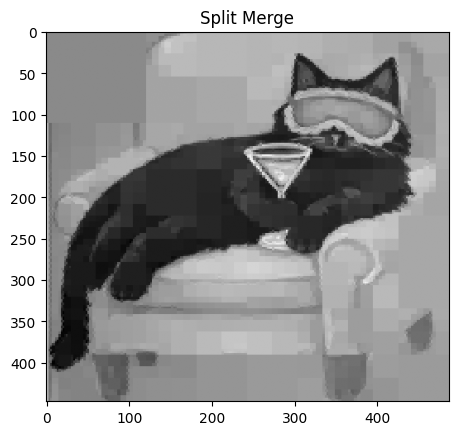

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img=cv2.imread("C:\\Users\\ind81\\OneDrive\\Pictures\\Screenshots\\Screenshot 2026-02-26 195009.png",0)

def split(img,th):
    h,w=img.shape
    if np.std(img)<th or h<4 or w<4:
        return np.ones((h,w))*np.mean(img)
    h2,w2=h//2,w//2
    q1=split(img[:h2,:w2],th)
    q2=split(img[:h2,w2:],th)
    q3=split(img[h2:,:w2],th)
    q4=split(img[h2:,w2:],th)
    top=np.hstack((q1,q2))
    bottom=np.hstack((q3,q4))
    return np.vstack((top,bottom))

res=split(img,10)
plt.imshow(res,cmap='gray')
plt.title("Split Merge")
plt.show()

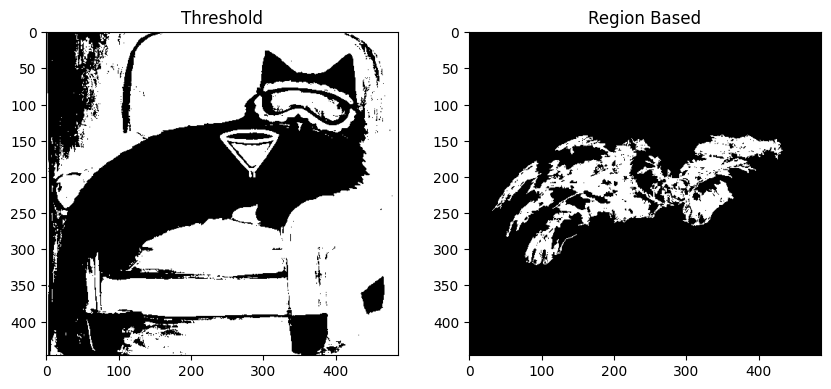

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img=cv2.imread("C:\\Users\\ind81\\OneDrive\\Pictures\\Screenshots\\Screenshot 2026-02-26 195009.png",0)

_,global_thresh=cv2.threshold(img,127,255,cv2.THRESH_BINARY)

h,w=img.shape
seg=np.zeros((h,w),dtype=np.uint8)
seed=(h//2,w//2)
stack=[seed]
threshold=10
seed_val=img[seed]

while stack:
    x,y=stack.pop()
    if seg[x,y]==0:
        seg[x,y]=255
        for dx in [-1,0,1]:
            for dy in [-1,0,1]:
                nx,ny=x+dx,y+dy
                if 0<=nx<h and 0<=ny<w:
                    if abs(int(img[nx,ny])-int(seed_val))<threshold:
                        stack.append((nx,ny))

plt.figure(figsize=(10,5))
plt.subplot(121),plt.imshow(global_thresh,cmap='gray'),plt.title("Threshold")
plt.subplot(122),plt.imshow(seg,cmap='gray'),plt.title("Region Based")
plt.show()